In [1]:
import sys
sys.path.append('../../')
import numpy as np

from samrfi import RadioRFI, RFIDataset, RFITraining

/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
from samrfi import RadioRFI

dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

original_calib = '/home/gpuhost002/ddeal/RFI-AI/one_antenna_3C129_rflag.ms'

datarfi_3C129 = RadioRFI(vis=original_calib, dir_path=dir_path)
datarfi_3C129.load(mode='DATA', ant_i=1) # using first two antennas


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:16<00:00, 16.20s/it]


(26, 4, 2048, 511)


In [17]:
datarfi_3C129.load(mode='FLAG', ant_i=1) # using first two antennas
datarfi_3C129.flags = np.abs(datarfi_3C129.ms_flags)


Loading data...


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:05<00:00,  5.79s/it]


In [4]:
datarfi_3C129.rfi_antenna_data = datarfi_3C129.rfi_antenna_data[0:2]
datarfi_3C129.flags = datarfi_3C129.flags[0:2]

In [5]:
datarfi_3C129.rfi_antenna_data.shape

(2, 4, 2048, 511)

In [6]:
datarfi_3C129.flags.shape

(2, 4, 2048, 511)

In [18]:
import numpy as np

# Suppose rfi_antenna_data has shape (num_baselines, num_pols, freq_size, time_size)
padded_data_list = []

for baseline in range(datarfi_3C129.rfi_antenna_data.shape[0]):
    pol_list = []  # will hold padded images for each polarization at this baseline
    for pol in range(datarfi_3C129.rfi_antenna_data.shape[1]):
        img = datarfi_3C129.rfi_antenna_data[baseline, pol]  # shape (freq_size, time_size)
        freq_pad = max(1024 - img.shape[0], 0)
        time_pad = max(1024 - img.shape[1], 0)
        
        padded_img = np.pad(img, ((0, freq_pad), (0, time_pad)), mode='wrap')
        pol_list.append(padded_img)
    
    # Stack all polarizations for this baseline into a single array
    pol_array = np.stack(pol_list)
    padded_data_list.append(pol_array)

# Finally, stack all baselines into one 4D array:
# shape: (num_baselines, num_pols, new_freq_size, new_time_size)
padded_data = np.stack(padded_data_list)

# Now padded_data contains the padded versions for all baselines/polarizations

In [19]:
import numpy as np

# Suppose flags has shape (num_baselines, num_pols, freq_size, time_size)
padded_data_list = []

for baseline in range(datarfi_3C129.flags.shape[0]):
    pol_list = []  # will hold padded images for each polarization at this baseline
    for pol in range(datarfi_3C129.flags.shape[1]):
        img = datarfi_3C129.flags[baseline, pol]  # shape (freq_size, time_size)
        freq_pad = max(1024 - img.shape[0], 0)
        time_pad = max(1024 - img.shape[1], 0)
        
        padded_img = np.pad(img, ((0, freq_pad), (0, time_pad)), mode='wrap')
        pol_list.append(padded_img)
    
    # Stack all polarizations for this baseline into a single array
    pol_array = np.stack(pol_list)
    padded_data_list.append(pol_array)

# Finally, stack all baselines into one 4D array:
# shape: (num_baselines, num_pols, new_freq_size, new_time_size)
padded_data_flags = np.stack(padded_data_list)

# Now padded_data contains the padded versions for all baselines/polarizations

In [20]:
datarfi_3C129.rfi_antenna_data = padded_data
datarfi_3C129.flags = padded_data_flags

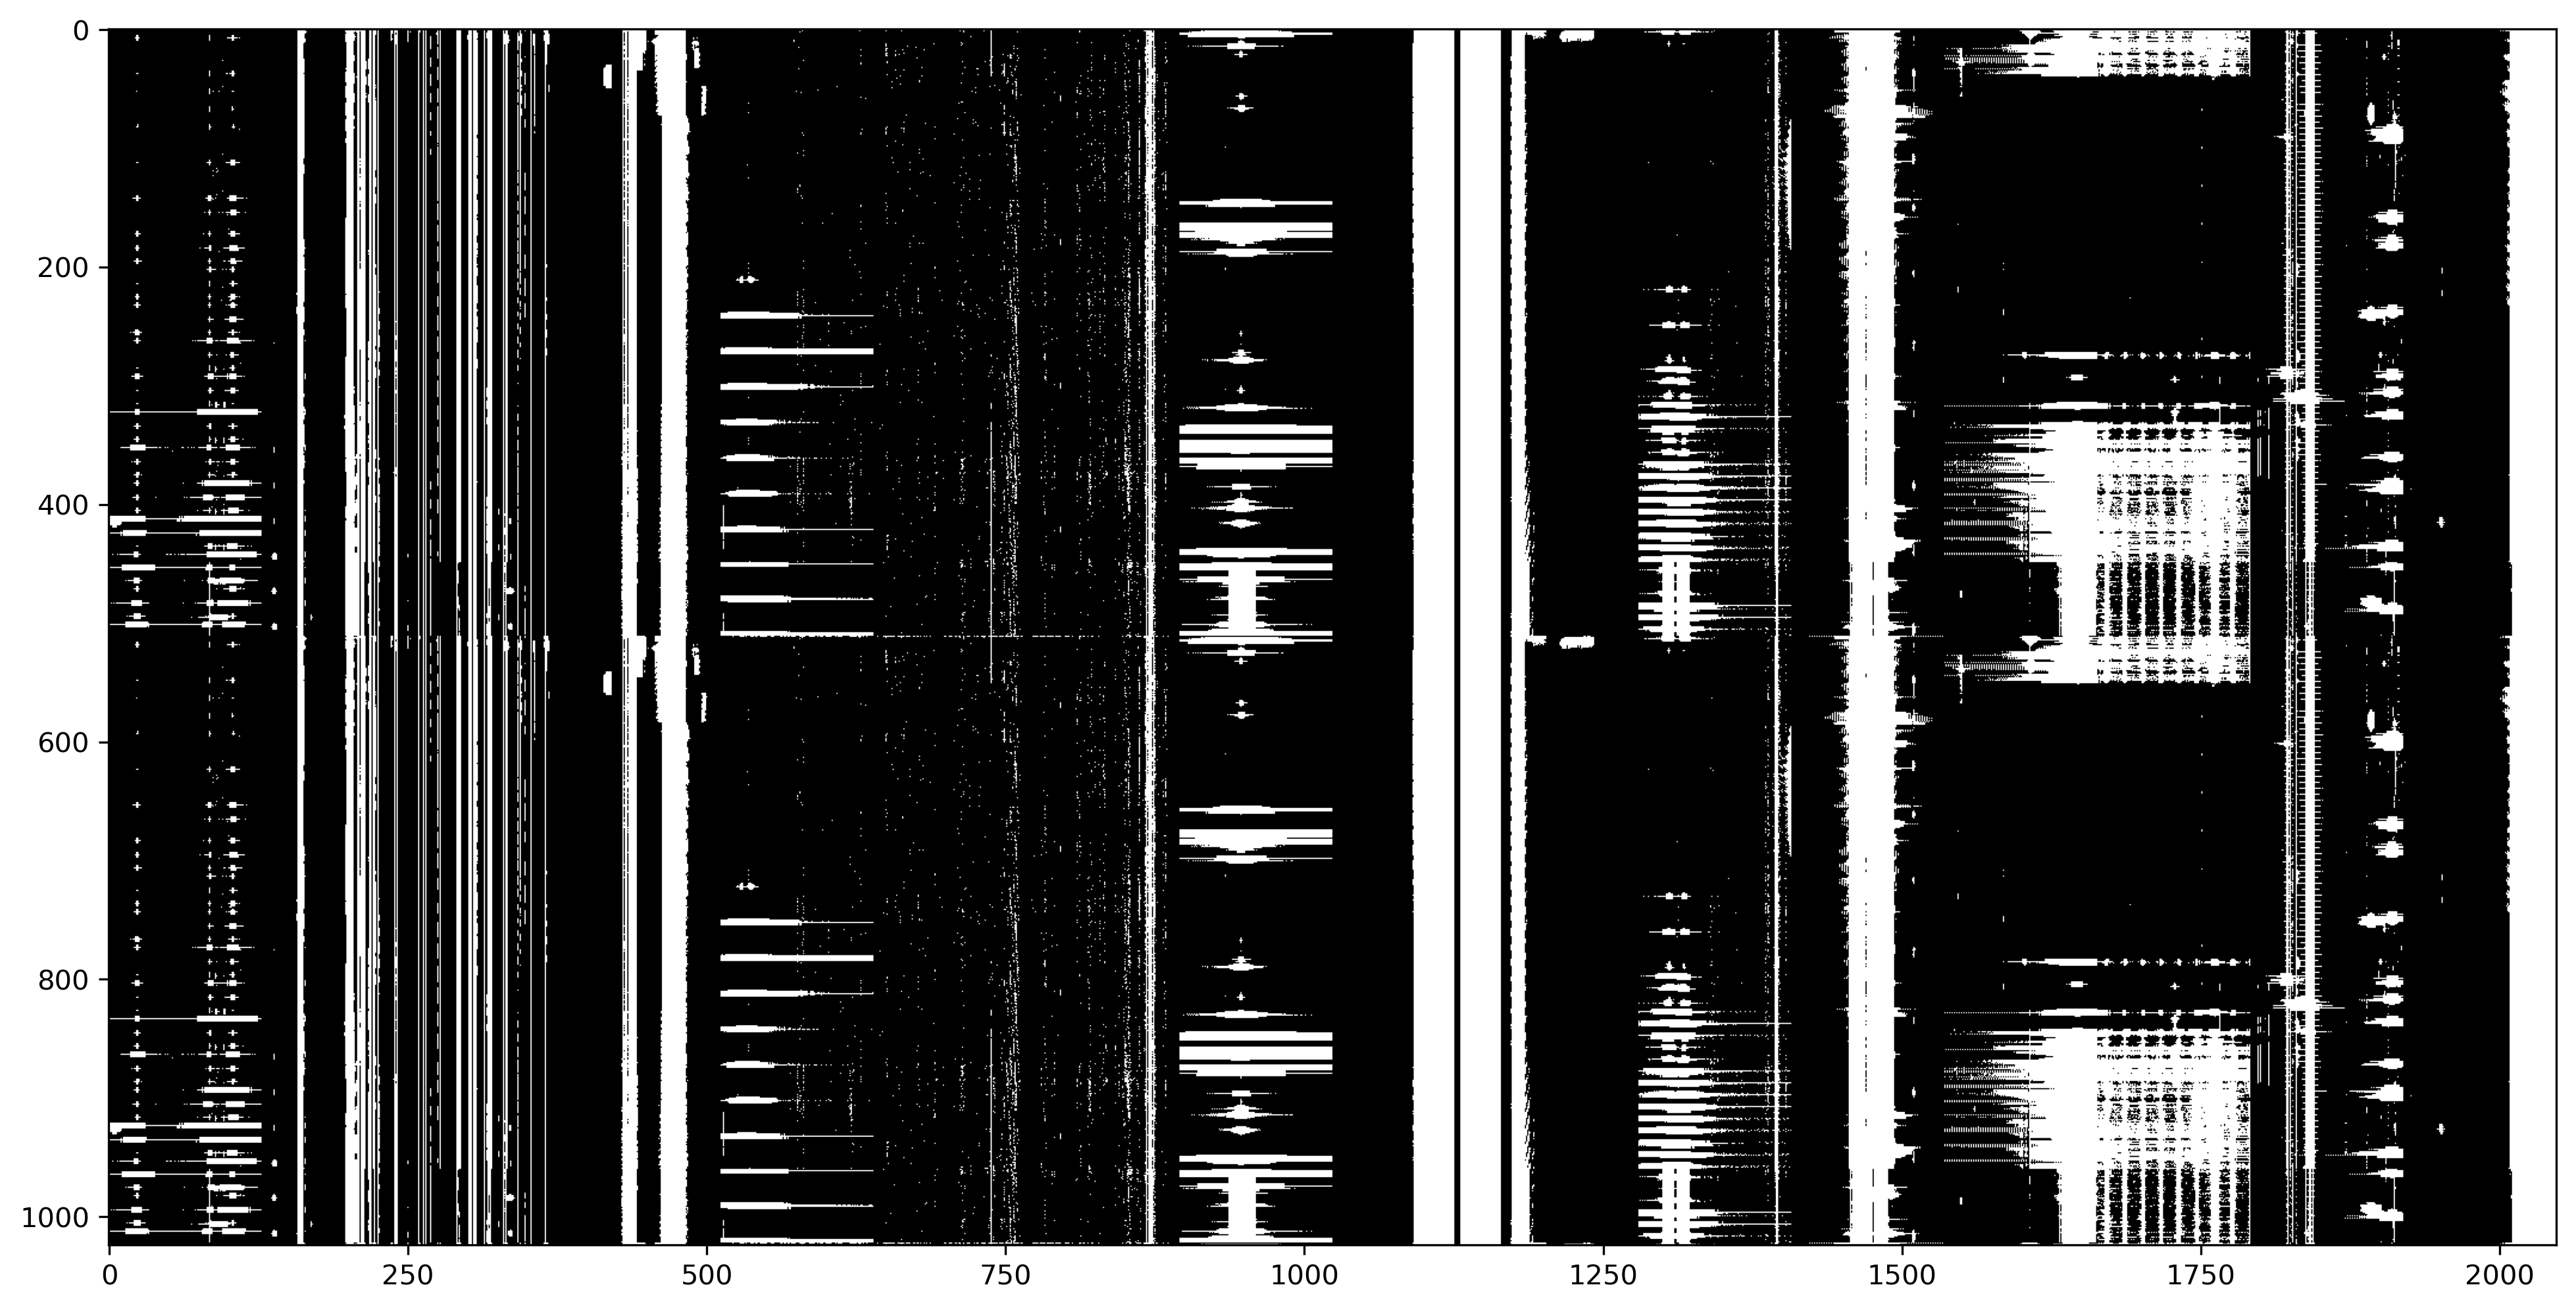

In [10]:
datarfi_3C129.plotter.plot(mode='FLAG', baseline=0, polarization=0)

In [21]:
rfi_dataset = RFIDataset(datarfi_3C129, dir_path=dir_path)
rfi_dataset.create_dataset(patch_size=1024, apply_stretching=False, custom_flag=True)


Applying median normalization only to 832 patches...


100%|██████████| 832/832 [00:12<00:00, 67.11it/s]



Applying median normalization only to 832 patches...


100%|██████████| 832/832 [00:10<00:00, 78.70it/s]


(832, 1024, 1024) (832, 1024, 1024)


In [12]:
np.array(rfi_dataset.dataset['image']).shape

(64, 1024, 1024, 3)

In [13]:
cd /home/gpuhost002/ddeal/RFI-AI/sam2/notebooks

/home/gpuhost002/ddeal/RFI-AI/sam2/notebooks


/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]



Training model...


100%|██████████| 208/208 [09:12<00:00,  2.66s/it]


EPOCH: 0
Mean loss: 1.0756006644895444


100%|██████████| 208/208 [09:12<00:00,  2.66s/it]


EPOCH: 1
Mean loss: 0.6436474154201838


...

100%|██████████| 208/208 [09:10<00:00,  2.64s/it]


EPOCH: 38
Mean loss: 0.31596689850378495


100%|██████████| 208/208 [09:09<00:00,  2.64s/it]


EPOCH: 39
Mean loss: 0.3145329042409475


<Figure size 640x480 with 0 Axes>

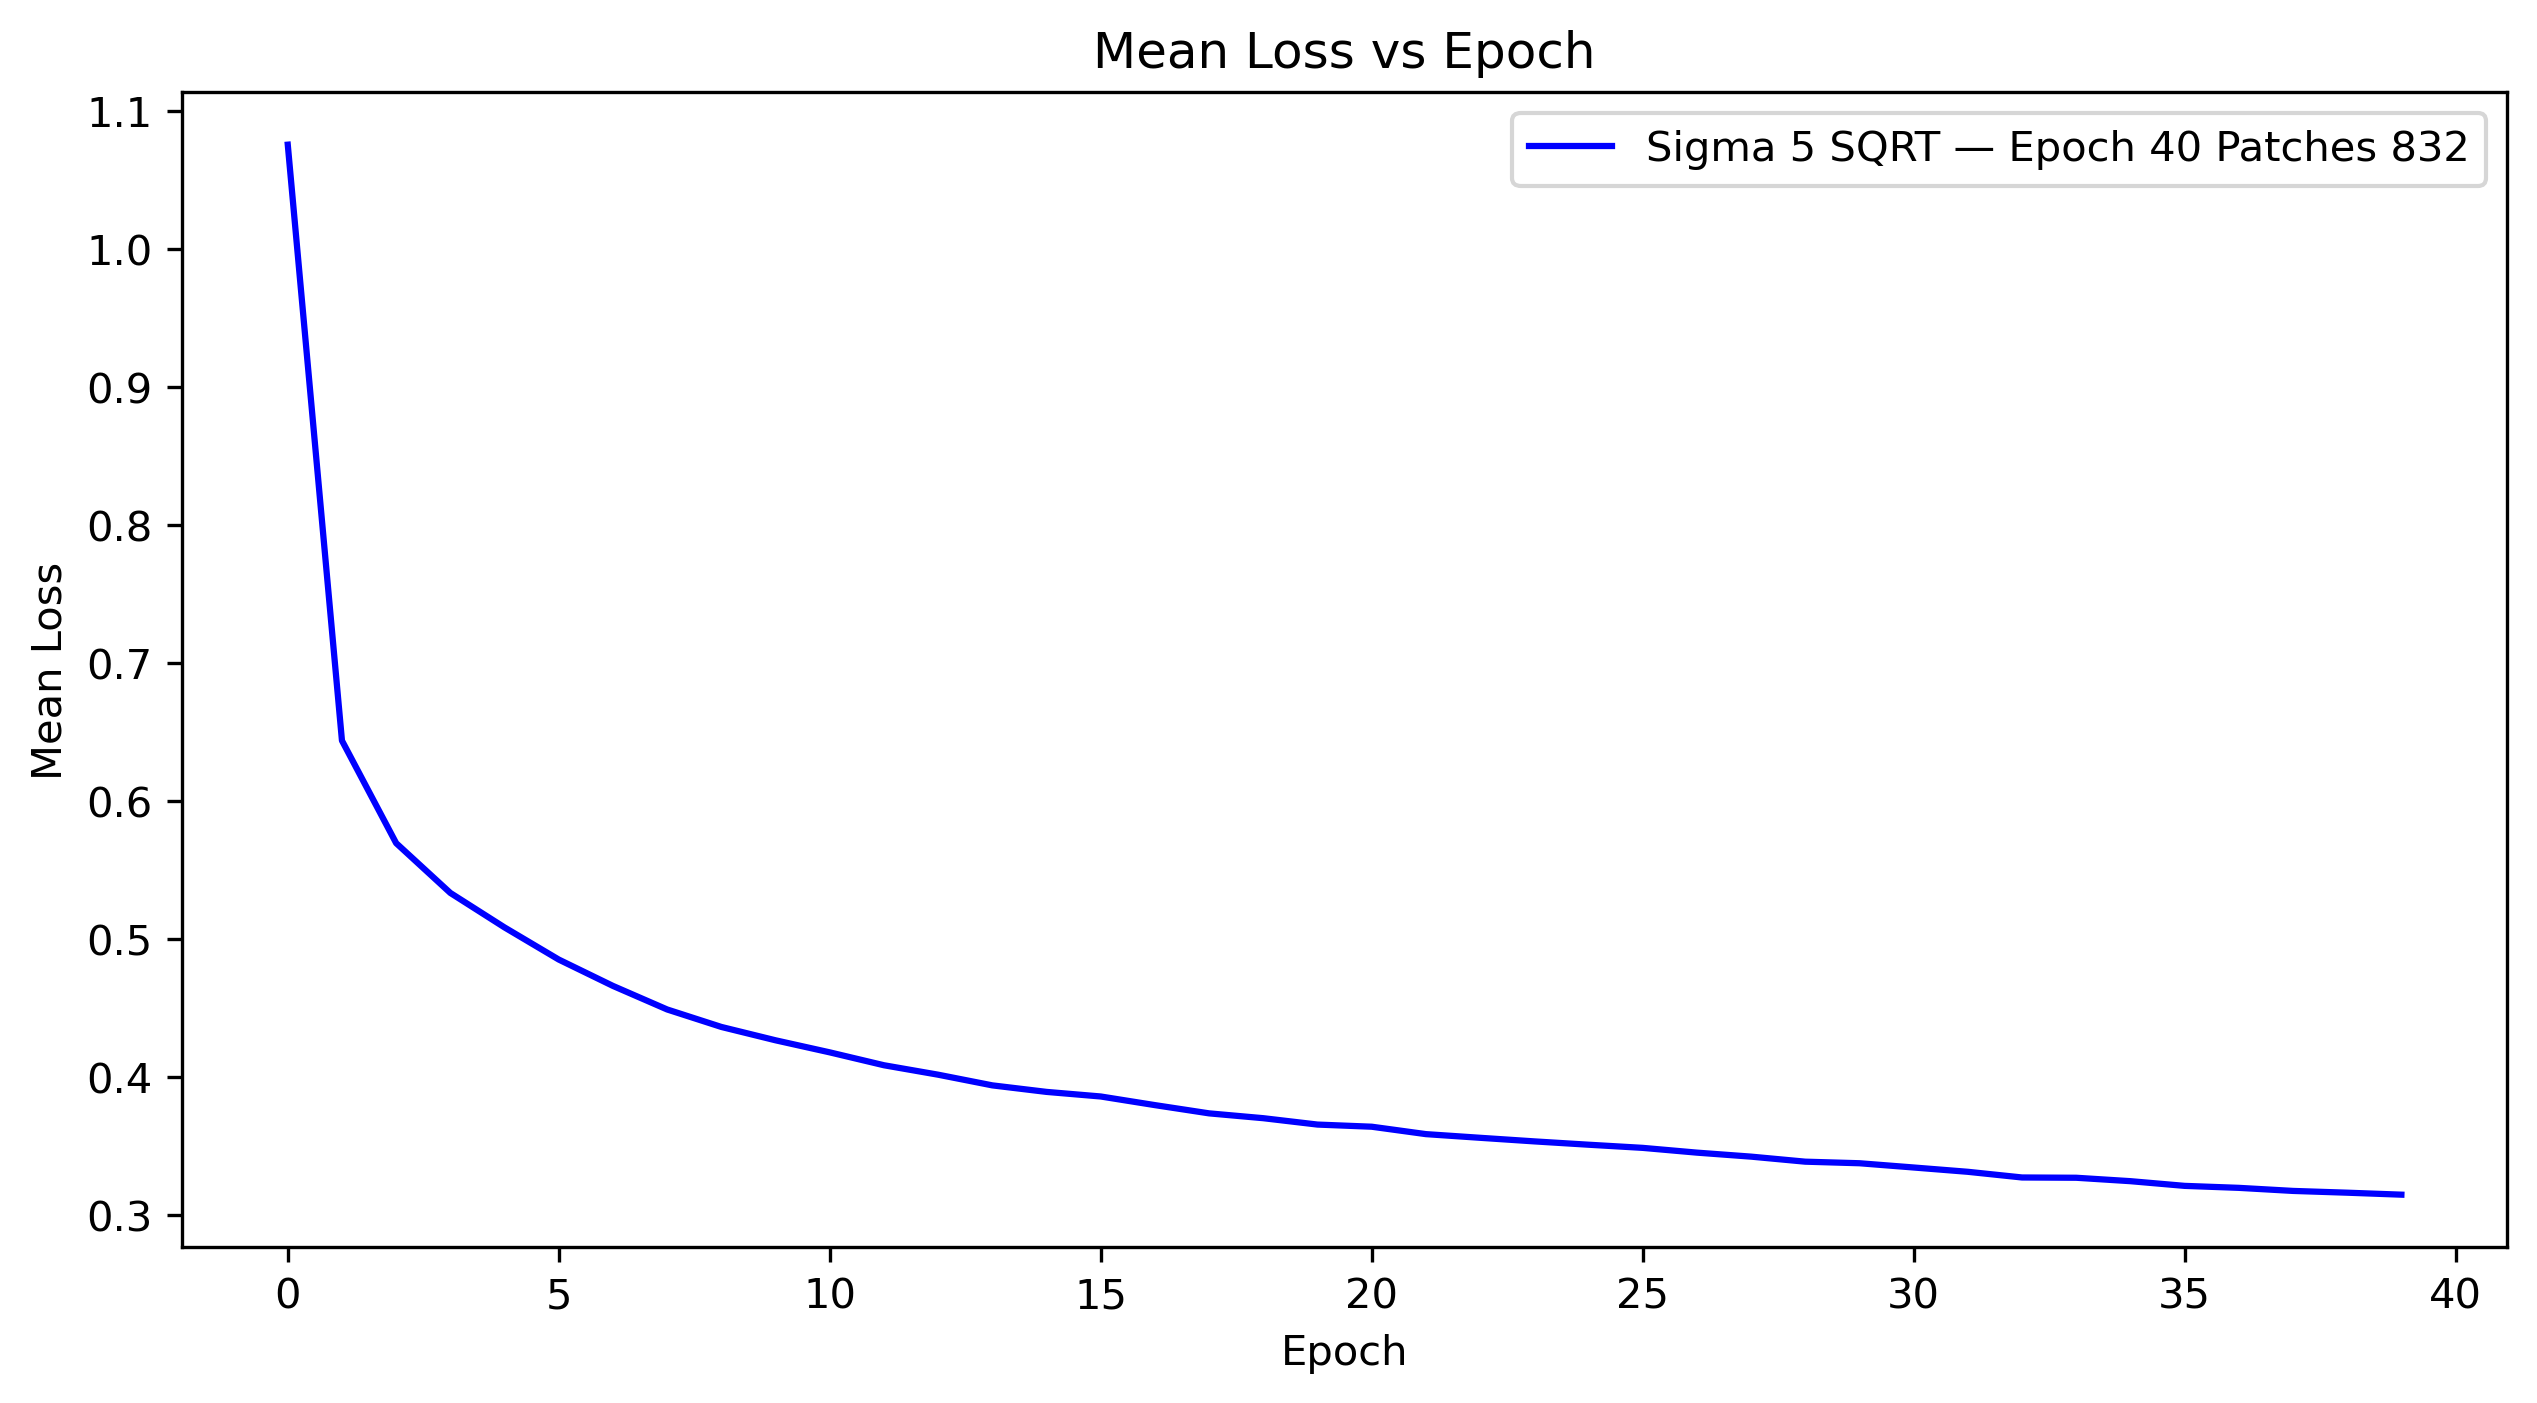

In [22]:
from samrfi import RFITraining 

new_model = RFITraining(rfi_dataset, device='cuda', dir_path=dir_path)
new_model.train(num_epochs=40, batch_size=4)

In [17]:
new_model.train_dataloader_sam1.dataset[0]['pixel_values'].shape

torch.Size([3, 1024, 1024])

In [18]:
new_model.train_dataloader_sam1.dataset[0]

{'pixel_values': tensor([[[-2.1008, -2.1179, -2.1179,  ..., -2.0152, -2.0665, -2.0494],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0323, -2.1008, -1.9980],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0837, -2.0665, -2.1008],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.0494, -2.0323, -2.0665],
          [-2.1008, -2.1179, -2.1179,  ..., -2.0152, -2.0665, -2.0494],
          [-2.1179, -2.1179, -2.1179,  ..., -2.0323, -2.1008, -1.9980]],
 
         [[-2.0182, -2.0357, -2.0357,  ..., -1.9307, -1.9832, -1.9657],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9482, -2.0182, -1.9132],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0007, -1.9832, -2.0182],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -1.9657, -1.9482, -1.9832],
          [-2.0182, -2.0357, -2.0357,  ..., -1.9307, -1.9832, -1.9657],
          [-2.0357, -2.0357, -2.0357,  ..., -1.9482, -2.0182, -1.9132]],
 
         [[-1.7870, -1.8044, -1.8044,  ..., -1.6999, -1.7522, -1.7347],
          [-

In [15]:
new_model_sam2 = RFITraining(rfi_dataset, device='cuda', dir_path=dir_path)

new_model_sam2.sam2_ckpt = "../checkpoints/sam2.1_hiera_large.pt"
new_model_sam2.sam2_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
new_model_sam2.train_sam2(num_epochs=2, batch_size=4)


Training SAM 2 model...


  0%|          | 0/16 [00:00<?, ?it/s]

Image shape: (1024, 1024, 3)


  0%|          | 0/16 [00:00<?, ?it/s]


ValueError: Input and output must have the same number of spatial dimensions, but got input with spatial dimensions of [] and output size of torch.Size([1024, 1024]). Please provide input tensor in (N, C, d1, d2, ...,dK) format and output size in (o1, o2, ...,oK) format.

In [56]:
for i in new_model.train_dataloader_sam1:
    print(i['pixel_values'].shape)

torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])


In [17]:
for i in new_model_sam2.train_dataloader:
    print(i['image'].shape)

torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])


torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])
torch.Size([4, 3, 1024, 1024])


In [22]:
new_model_sam2.train_dataloader['ground_truth_mask'].shape

TypeError: 'DataLoader' object is not subscriptable

In [ ]:
for step, batch in enumerate(train_dataloader): # batch["image"] has shape [B, 3, H, W] # Convert to 5D by splitting out the batch dimension: 
    for i in range(batch["image"].shape[0]): 
        single_image = batch["image"][i] # shape [3, H, W] single_mask = batch["ground_truth_mask"][i] # shape [H, W]

In [20]:
for i in new_model_sam2.train_dataloader:
    print(i["input_boxes"][0])


tensor([0, 0, 0, 0])
tensor([  0,  48, 257,   0])
tensor([  0,   0, 257,   0])
tensor([0, 0, 0, 0])
tensor([243,  61,  66,  59])
tensor([  0,   0, 255,   0])
tensor([58,  0, 64,  0])
tensor([ 0, 49,  0,  0])
tensor([257,   0,   0,   0])
tensor([0, 0, 0, 0])
tensor([0, 0, 0, 0])
tensor([0, 0, 0, 0])
tensor([0, 0, 0, 0])
tensor([ 0, 58,  0,  0])
tensor([255,   0, 242,   0])
tensor([  0, 249,   0,   0])
